# Complementaria Semana 9: Cadenas de Markov en Python II

<h2 style="color: #ADD8E6;">Objetivos de aprendizaje</h2>


Al finalizar esta sesión, el estudiante será capaz de:

1. Distinguir entre distribución transitoria y distribución en estado estable.
2. Visualizar cómo la distribución conjunta evoluciona y converge al estado estable.
3. Calcular distribuciones marginales, condicionales, valores esperados, varianzas y probabilidades de eventos.
4. Responder preguntas de negocio (costos, utilización) usando las distribuciones.
5. Calcular e interpretar tiempos de primera pasada y tiempos de ocupación.

<h2 style="color: #ADD8E6;">Ejercicio de un hospital en tiempo continuo (Continuación)</h2>

Considere un hospital con $B = 20$ camas. Hay dos tipos de pacientes que usan este hospital. Los pacientes de tipo $i\ (i=1,2)$ llegan según un proceso de Poisson con tasa $\lambda_1 = 6.5$ y $\lambda_2 = 3$ pacientes por hora y requieren un servicio independiente e idénticamente distribuido (iid) con tiempos de servicio que siguen una distribución exponencial con parámetros $\mu_1 = 2$ y $\mu_2 = 1.5$ pacientes por hora. El hospital utiliza la siguiente política: reserva $b = 5$ camas para pacientes de tipo 1. Así, cuando un paciente de tipo 1 llega, se le admite en el hospital siempre que haya una cama disponible. Sin embargo, un paciente de tipo 2 es admitido solo si el número de pacientes de tipo 2 que actualmente ocupan camas es menor que $B-b$.

Se le ha solicitado modelar la anterior situación definiendo claramente variables de estado, espacios de estado y matriz de transición o generadora según sea el caso.


**Variables de estado:**
- $X\left(t\right)$: El número de pacientes tipo 1 en el tiempo $t$.
- $Y\left(t\right)$: El número de pacientes tipo 2 en el tiempo $t$.
- $Z\left(t\right)$: $\{X\left(t\right),\ Y\left(t\right)\}$.

**Espacio de estados:**

$$
S_X=\{0,\ 1,\ 2,\ 3,\ \ldots,B\}
$$

$$
S_Y=\{0,\ 1,\ 2,\ 3,\ \ldots,B-b\}
$$

$$
S_Z=\{(i,j):0\le i\le B,\ 0\le j\le B-b\}
$$

**Matriz generadora:**

$$
Q((i,j),(i',j')) = \begin{cases}
\lambda_1, & \text{si } i' = i + 1,\; j' = j,\; i < B, \\[1mm]
\lambda_2, & \text{si } j' = j + 1,\; i' = i,\; j < B - b, \\[1mm]
i \cdot \mu_1, & \text{si } i' = i - 1,\; j' = j,\; i > 0, \\[1mm]
j \cdot \mu_2, & \text{si } j' = j - 1,\; i' = i,\; j > 0, \\[1mm]
0, & \text{en otro caso (d.l.c.)}.
\end{cases}
$$

In [1]:
# Creacion de la cadena de markov para el hospital

import numpy as np
import matplotlib.pyplot as plt
from jmarkov.ctmc import ctmc

# Definimos los parámetros
B = 20  # Número total de camas
b = 5   # Número de camas reservadas para pacientes tipo 1
lambda_1 = 6.5  # Tasa de llegada de pacientes tipo 1 (por hora)
lambda_2 = 3  # Tasa de llegada de pacientes tipo 2 (por hora)
mu_1 = 2      # Tasa de salida de pacientes tipo 1 (por hora)
mu_2 = 1.5    # Tasa de salida de pacientes tipo 2 (por hora)

# Dimensión de la matriz Q
num_estados = (B + 1) * (B - b + 1)

# Inicializamos la matriz Q con ceros
Q_evaluar = np.zeros((num_estados, num_estados), dtype=float)

# Función para mapear (i, j) a índice en la matriz Q
def index(i, j):
    return i * (B - b + 1) + j

# Llenar la matriz Q
for i in range(B + 1):
    for j in range(B - b + 1):
        idx = index(i, j)

        # Llegada de un paciente tipo 1
        if i < B:
            Q_evaluar[idx, index(i + 1, j)] = lambda_1

        # Llegada de un paciente tipo 2 (si hay espacio disponible)
        if j < B - b:
            Q_evaluar[idx, index(i, j + 1)] = lambda_2

        # Salida de un paciente tipo 1
        if i > 0:
            Q_evaluar[idx, index(i - 1, j)] = i * mu_1

        # Salida de un paciente tipo 2
        if j > 0:
            Q_evaluar[idx, index(i, j - 1)] = j * mu_2

# Llenar la diagonal con la suma negativa de las filas de la matriz
for i in range(num_estados):
    Q_evaluar[i, i] = -np.sum(Q_evaluar[i, :])
    
from jmarkov.ctmc import ctmc

# Crear la cadena de Markov en tiempo continuo usando jmarkov
hospital_chain = ctmc(Q_evaluar)

In [2]:
# Funciones auxiliares que usaremos en toda la sesión
def vector_a_matriz(pi_vec):
    # Convierte vector de probabilidades a matriz (i, j)
    M = np.zeros((B + 1, B - b + 1))
    for i in range(B + 1):
        for j in range(B - b + 1):
            M[i, j] = pi_vec[index(i, j)]
    return M

def plot_heatmap(pi_mat, titulo, ax, max_i=10, max_j=10):
    region = pi_mat[:max_i, :max_j]
    im = ax.imshow(region.T, origin='lower', aspect='auto', cmap='YlOrRd')
    ax.set_xlabel('Pacientes Tipo 1 (i)')
    ax.set_ylabel('Pacientes Tipo 2 (j)')
    ax.set_title(titulo)
    plt.colorbar(im, ax=ax, shrink=0.8)
    for i in range(min(8, max_i)):
        for j in range(min(8, max_j)):
            val = region[i, j]
            if val > 0.004:
                ax.text(i, j, f'{val:.3f}', ha='center', va='center', fontsize=6,
                       color='white' if val > 0.02 else 'black')
    return im

<h3 style="color: #ADD8E6;">Preguntas</h3>

1. ¿Cuál es la probabilidad de que haya 4 pacientes tipo 2 luego de 5 horas? Asuma que al inicio había un paciente de tipo 1 y un paciente de tipo 2.
2. Calcule la varianza del número total de pacientes en el hospital tras 2 horas y 6 horas, dado que al inicio el sistema está vacío. Compare los resultados obtenidos.
3. Calcule la probabilidad de que haya más pacientes tipo 1 que tipo 2 a largo plazo.
4. Genere una gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2 en función del tiempo, desde 0 hasta 24 horas. Compare con el valor obtenido en el punto anterior.
5. Si cada paciente tipo 1 genera un costo operativo por insumos de 100 pesos por hora y cada paciente tipo 2 un costo de 80 pesos por hora, ¿cuál es el costo operativo total esperado por hora a largo plazo?
6. Actualmente el hospital se encuentra completamente vacío, ¿cuánto tiempo pasará en promedio para que por primera vez se tengan 10 pacientes tipo 1 y 3 pacientes tipo 2?
7. Si se observa el sistema durante una semana, ¿cuánto tiempo esperado pasará el hospital con más de 3 pacientes de tipo 1 y menos de 2 pacientes de tipo 2, dado que había uno solo de cada tipo al inicio.

<h4 style="color: #ADD8E6;">1. Cálculo de la probabilidad de que haya 4 pacientes tipo 2 luego de 5 horas, partiendo de que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2.</h4>



En la sesión anterior nos pedían la transición de un estado inicial a un estado final en un lapso de tiempo definido. No obstante, para esta pregunta si bien tenemos el estado inicial y el tiempo que transcurre, el estado final solo nos está indicando el número de pacientes de tipo 2 (4 pacientes), pero no nos dicen nada respecto a los pacientes tipo 1. Dado que no está especificado, debemos tener en cuenta todas las posibilidades en las que tenemos 4 pacientes de tipo 2 y cualquier valor $S_X=\{0,\ 1,\ 2,\ 3,\ \ldots,B\}$ para los pacientes tipo 1. Esta pregunta se trata de un problema de probabilidades transitorias de la forma:

$$
\pi(t) = \pi(0) e^{Qt}
$$

El primer paso es definir el vector de estados iniciales. Dado que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2 inicialmente, el vector de estados iniciales es:

$$
\begin{split}
\pi(0)=\begin{cases}
1, & i=1,\ j=1,\\
0, & \text{d.l.c.}
\end{cases}
\end{split}
$$


Como nos interesa la probabilidad de que haya exactamente $4$ pacientes tipo 2, independientemente de la cantidad de pacientes tipo 1, necesitamos la **distribución marginal** de $Y$ a $t=5$, esta la obtenemos al debemos sumar las probabilidades de todo $S_X$ dado que $Y=4$, para un periodo de 5 horas:

$$
\sum_{i\in S_X} \big[\ \pi(0)\, e^{Q\,(5)}\ \big]_{(i,4)}
$$

Para poder encontrar este valor el primer paso es establecer el vector de estado inicial con 1 paciente de tipo 1 y 1 paciente de tipo 2.

In [3]:
# --------------------------------------------------------------------
# Pregunta 1: ¿Cuál es la probabilidad de que hayan 4 pacientes tipo 2 luego de 5 horas?
# Partiendo de que el hospital tenía 1 paciente tipo 1 y 1 paciente tipo 2.
alpha = np.zeros(num_estados)
alpha[index(1,1)] = 1

Calculamos la distribución del sistema a las 5 horas.

In [4]:
probs_transitorias_5h = hospital_chain.transient_probabilities(t=5, alpha=alpha)

Para responder a la pregunta debemos calcular las probabilidades marginales:

In [6]:
# Calcular la distribución marginal de Y(5) para todos los valores de j
prob_marg_tipo2 = [sum(probs_transitorias_5h[index(i, j)]
                        for i in range(B + 1)) 
                        for j in range(B - b + 1)]

# Mostrar la probabilidad específica para j = 4
print(f"Probabilidad de que haya 4 pacientes tipo 2 luego de 5 horas: {prob_marg_tipo2[4]:.6f}")

Probabilidad de que haya 4 pacientes tipo 2 luego de 5 horas: 0.090174


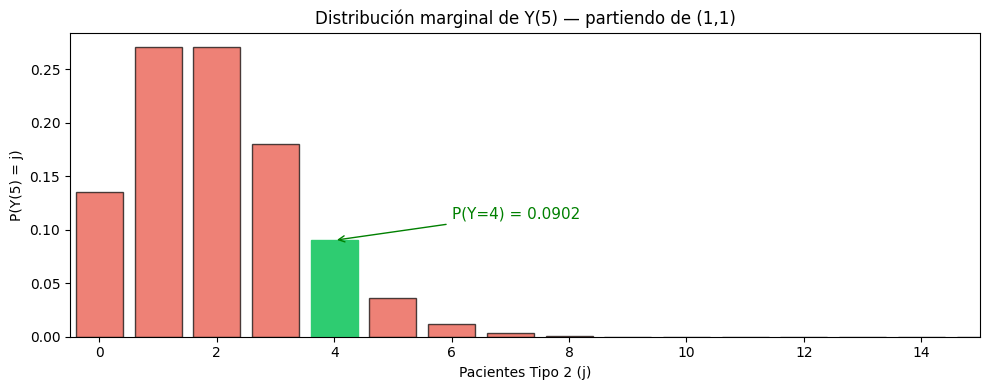

In [7]:
# Visualizar la marginal completa de Y
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(B - b + 1), prob_marg_tipo2, color='#e74c3c', edgecolor='black', alpha=0.7)
bars[4].set_color('#2ecc71')  # Resaltar j=4
bars[4].set_alpha(1.0)
ax.set_xlabel('Pacientes Tipo 2 (j)')
ax.set_ylabel('P(Y(5) = j)')
ax.set_title('Distribución marginal de Y(5) — partiendo de (1,1)')
ax.set_xlim(-0.5, B - b)
ax.annotate(f'P(Y=4) = {prob_marg_tipo2[4]:.4f}', xy=(4, prob_marg_tipo2[4]), xytext=(6, prob_marg_tipo2[4] + 0.02),
            arrowprops=dict(arrowstyle='->', color='green'), fontsize=11, color='green')
plt.tight_layout()
plt.show()

<h4 style="color: #ADD8E6;">2. Cálculo de la varianza del número total de pacientes tras 2 horas</h4>

Sea $T(t) = X(t) + Y(t)$ el número total de pacientes, podemos calcular su varianza como:

$$\text{Var}(T) = E[T^2] - (E[T])^2 = \sum_{(i,j) \in S} (i+j)^2 \pi_{(i,j)}(t) - \left(\sum_{(i,j) \in S} (i+j) \pi_{(i,j)}(t)\right)^2$$


> **Nota:** $T = X + Y$ es una **variable aleatoria nueva** que se construye como función de $(X, Y)$. Podemos calcular su distribución completa, no solo su varianza.

Para implementarlo primero definimos los vectores de probabilidades transitorias para 1 y 6 horas dado que el hospital estaba vacio al inicio.

In [8]:
# --------------------------------------------------------------------
# Pregunta 2: Calcule la varianza del número total de pacientes en el hospital tras 2 horas y 6 horas,
# dado que al inicio está vacío. Compare los resultados obtenidos.

# vector de estados inciales para hospital vacio (0, 0)
alpha = np.zeros(num_estados)
alpha[index(0, 0)] = 1

# Probabilidades transitorias en 2 horas
probs_transitorias_2h = hospital_chain.transient_probabilities(t=2, alpha=alpha)

# Probabilidades transitorias en 6 horas
probs_transitorias_6h = hospital_chain.transient_probabilities(t=6, alpha=alpha)

Para la siguiente parte podemos definir una función que calcule la varianza en términos del valor esperado.

In [9]:
# Función para calcular varianza dada una distribución de probabilidad
def calcular_varianza(probs):
    esperanza = sum((i + j) * probs[index(i, j)]
                    for i in range(B + 1)
                    for j in range(B - b + 1))
    
    esperanza_cuadrado = sum(probs[index(i, j)] * (i + j) ** 2
                             for i in range(B + 1)
                             for j in range(B - b + 1))
    varianza = esperanza_cuadrado - esperanza ** 2
    return varianza

Ahora respondemos a la pregunta llamando esa función y utilizando como parámetro los dos vectores de probabilidades pasadas 1 hora y 6 horas:

In [10]:
# Cálculo de varianza en los distintos momentos

varianza_2h = calcular_varianza(probs_transitorias_2h)
varianza_6h = calcular_varianza(probs_transitorias_6h)

# Mostrar resultados
print(f"Varianza del número de pacientes tras 2 horas: {varianza_2h:.3f}")
print(f"Varianza del número de pacientes tras 6 horas: {varianza_6h:.3f}")

Varianza del número de pacientes tras 2 horas: 5.091
Varianza del número de pacientes tras 6 horas: 5.250


<h4 style="color: #ADD8E6;">3. Cálculo estado estable para la condición X &gt; Y</h4>

Para calcular la probabilidad de que en el largo plazo (estado estable) haya más pacientes tipo 1 que tipo 2, primero definimos $\pi_{(i,j)}$ como la probabilidad límite de que el sistema se encuentre en el estado con $i$ pacientes de tipo 1 y $j$ pacientes de tipo 2.

Estas probabilidades se obtienen al resolver el sistema de ecuaciones de balance global de la cadena:

$$
\pi \mathbb{Q} = 0
$$

Sujeto a la restricción de normalización, donde la suma de todas las probabilidades debe ser igual a 1:

$$
\sum_{i=0}^{B} \sum_{j=0}^{B-b} \pi_{(i,j)} = 1
$$

Una vez hallado el vector de probabilidades en estado estable $\pi$, la probabilidad de que haya estrictamente más pacientes tipo 1 que tipo 2 en el largo plazo se define como la suma de las probabilidades de todos los estados $(i,j)$ que cumplen la condición $i > j$:

$$
\lim_{t \to \infty} P(X(t) > Y(t)) = \sum_{(i,j) \in S, i > j} \pi_{(i,j)}
$$

In [11]:
# --------------------------------------------------------------------
# Pregunta 3: Calcule la probabilidad de que haya más pacientes tipo 1 que tipo 2 a largo plazo.

# Calcular la distribución en estado estable
pi_estable = hospital_chain.steady_state()

# Sumar las probabilidades donde i > j en estado estable
prob_mas_1_estable = sum(pi_estable[index(i, j)]
                         for i in range(B + 1)
                         for j in range(B - b + 1)
                         if i > j)

print(f"Probabilidad de que haya más pacientes tipo 1 que tipo 2 en estado estable: {prob_mas_1_estable:.6f}")

Probabilidad de que haya más pacientes tipo 1 que tipo 2 en estado estable: 0.625781


De manera similar a como hicimos en análisis transitorio, podemos realizar una visualización del estado estable por paciente en un mapa de calor

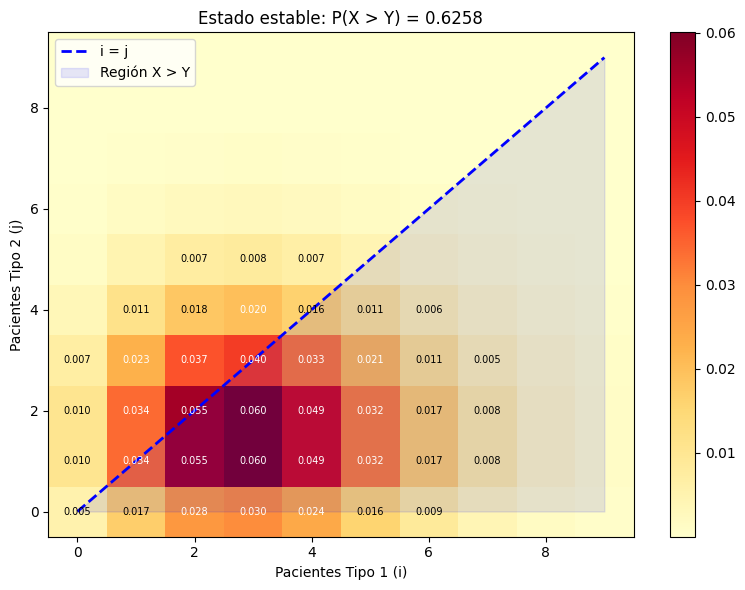

In [16]:
# Visualizar en el mapa de calor y resaltar la región i > j
fig, ax = plt.subplots(figsize=(8, 6))
max_show = 10
pi_ss_mat = vector_a_matriz(pi_estable)
region = pi_ss_mat[:max_show, :max_show]
im = ax.imshow(region.T, origin='lower', aspect='auto', cmap='YlOrRd')

# Dibujar la línea i = j
ax.plot(range(max_show), range(max_show), 'b--', linewidth=2, label='i = j')
ax.fill_between(range(max_show), 0, range(max_show), alpha=0.1, color='blue', label='Región X > Y')

ax.set_xlabel('Pacientes Tipo 1 (i)')
ax.set_ylabel('Pacientes Tipo 2 (j)')
ax.set_title(f'Estado estable: P(X > Y) = {prob_mas_1_estable:.4f}')
ax.legend()

for i in range(10):
    for j in range(10):
        val = region[i, j]
        if val > 0.005:
            ax.text(i, j, f'{val:.3f}', ha='center', va='center', fontsize=7,
                   color='white' if val > 0.02 else 'black')
            
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


<h4 style="color: #ADD8E6;">4. Generación de la gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2 en función del tiempo (0 a 24 horas)</h4>

Para este punto calculamos inicialmente la probabilidad para cada punto de tiempo en el intervalo de 0 a 24 horas. Esto lo guardamos en un vector que graficamos de la sigueinte forma utilizando `matplotlib`:

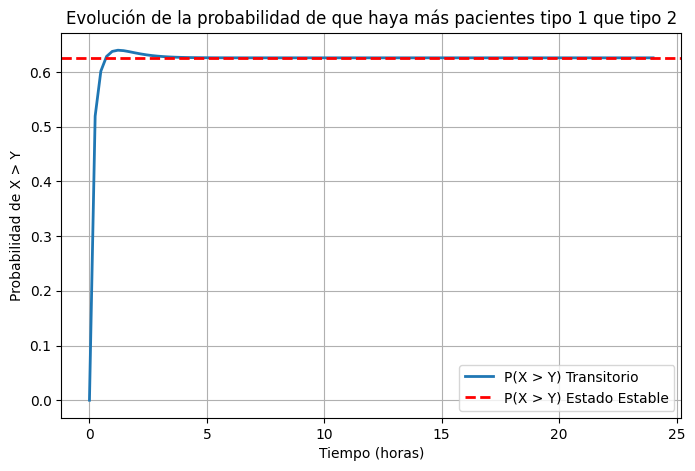

In [13]:
# --------------------------------------------------------------------
### Pregunta 4: Genere una gráfica de la probabilidad de que haya más pacientes tipo 1 que tipo 2
#  en función del tiempo, desde 0 hasta 24 horas. Compare con el valor obtenido en el punto anterior.

# Definir tiempos de evaluación
puntos_de_tiempo = np.linspace(0, 24, 100)

# Estado inicial: hospital vacío
alpha_vacio = np.zeros(num_estados)
alpha_vacio[index(0, 0)] = 1

# Calcular la distribución transitoria para cada punto en el tiempo
probabilidad_mas_tipo_1 = []

for t in puntos_de_tiempo:
    probs_transitorias_t = hospital_chain.transient_probabilities(t=t, alpha=alpha_vacio)
    prob_mas_1 = sum(probs_transitorias_t[index(i, j)]
                     for i in range(B + 1)
                     for j in range(B - b + 1)
                     if i > j)
    probabilidad_mas_tipo_1.append(prob_mas_1)


# Graficar la evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2
plt.figure(figsize=(8, 5))
plt.plot(puntos_de_tiempo, probabilidad_mas_tipo_1, label="P(X > Y) Transitorio", linewidth=2)

# Añadir una línea horizontal roja para el estado estable
plt.axhline(y=prob_mas_1_estable, color='r', linestyle='--', label="P(X > Y) Estado Estable", linewidth=2)

plt.xlabel("Tiempo (horas)")
plt.ylabel("Probabilidad de X > Y")
plt.title("Evolución de la probabilidad de que haya más pacientes tipo 1 que tipo 2")
plt.legend()
plt.grid(True)
plt.show()

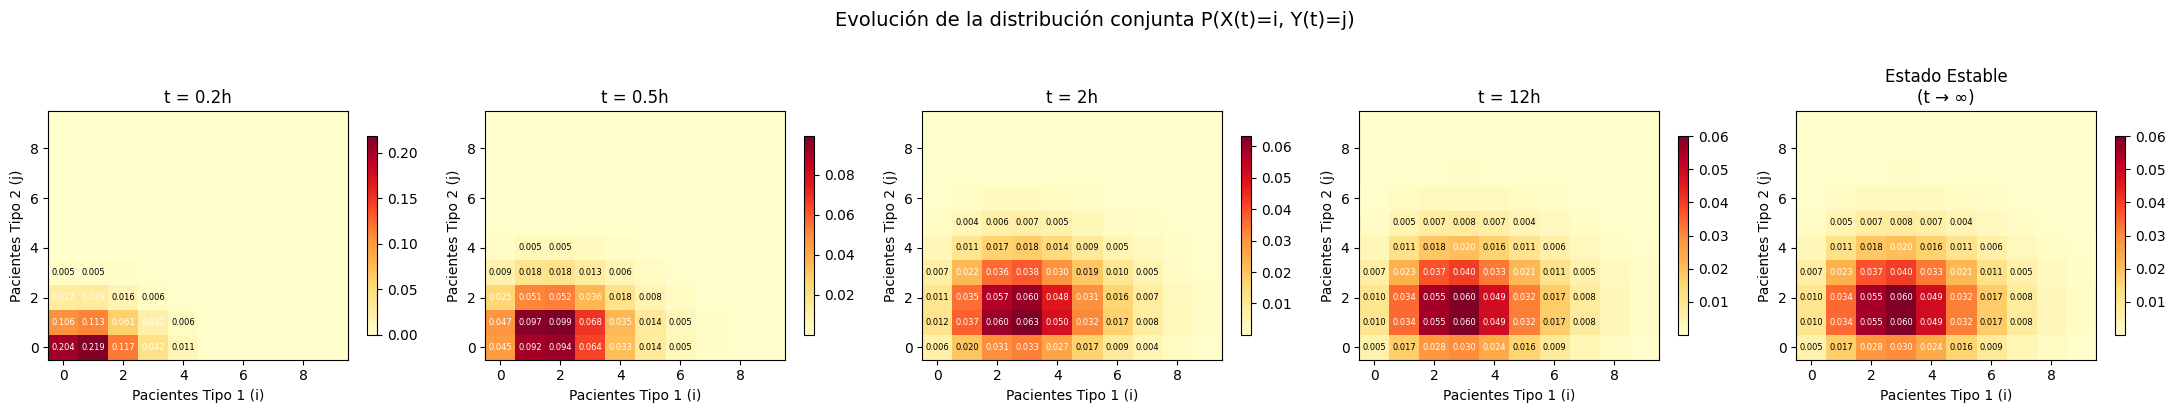

In [17]:
# Calcular distribuciones en varios instantes
tiempos_snap = [0.2, 0.5, 2, 12]
distribuciones = {}
for t_val in tiempos_snap:
    distribuciones[t_val] = hospital_chain.transient_probabilities(t=t_val, alpha=alpha_vacio)

# Visualización con snapshots de la distribución
fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax_idx, t_val in enumerate(tiempos_snap):
    pi_mat = vector_a_matriz(distribuciones[t_val])
    plot_heatmap(pi_mat, f't = {t_val}h', axes[ax_idx], max_i=10, max_j=10)

# Estado estable
plot_heatmap(pi_ss_mat, 'Estado Estable\n(t → ∞)', axes[4], max_i=10, max_j=10)

plt.suptitle('Evolución de la distribución conjunta P(X(t)=i, Y(t)=j)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


<h4 style="color: #ADD8E6;">5. Cálculo del costo operativo esperado en estado estable</h4>

Para calcular el costo operativo por hora, utilizamos la definición del valor esperado para variables aleatorias discretas, y multiplicamos el costo asociado a cada estado por la probabilidad a largo plazo de estar en dicho estado, y sumamos sobre todo el espacio de estados $S_X$.

Sea $C$ la función de costo para un estado $(i, j)$ tal que:
$$
C(i, j) = 100i + 80j
$$

Entonces el costo operativo total esperado por hora, $\mathbb{E}[C]$, se formula como:

$$
\mathbb{E}[C] = \sum_{(i,j) \in S_x} C(i,j) \pi_{(i,j)} = \sum_{i=0}^{B}\ \sum_{j=0}^{B-b} \left( 100i + 80j \right) \pi_{(i,j)}
$$

Para la implementación utilizamos el vector de probabilidades en estado estable definido previamente `pi_estable`. Posteriormente, multiplicamos estas probabilidaes por un vector con los costos asociados a cada estado y sumamos los valores para hallar el valor esperado.

In [18]:
# --------------------------------------------------------------------
# Pregunta 5: Si cada paciente tipo 1 genera un costo operativo por insumos de 100 pesos por hora y cada paciente
#  tipo 2 un costo de 80 pesos por hora, ¿cuál es el costo operativo total esperado por hora a largo plazo?

# Construir el vector de costos para cada estado (i pacientes tipo 1, j pacientes tipo 2)
costos_estados = np.zeros(num_estados)
for i in range(B + 1):
    for j in range(B - b + 1):
        costos_estados[index(i, j)] = (100 * i) + (80 * j)

# El costo esperado es la suma del producto de las probabilidades límite y los costos
costo_esperado_largo_plazo = sum(pi_estable * costos_estados)

print(f"Costo operativo total esperado por hora: ${costo_esperado_largo_plazo:.2f}")

Costo operativo total esperado por hora: $485.00


<h4 style="color: #ADD8E6;">6. Tiempo de primera pasada al estado (1, 3)</h4>

El tiempo promedio de primera pasada al estado objetivo (1, 3) se denota $m_{(0,0)\to(1,3)}$. Para encontrarlo se debe resolver el sistema lineal:

$$
r(i,j)\,m_{(i,j)\to(1,3)}
= 1 + \sum_{(k,\ell)\neq(1,3)} q_{(i,j),(k,\ell)}\, m_{(k,\ell)\to(1,3)}
$$
Equivalente a resolver por el método de la matriz recortada $\bar{Q}$ igual a la matriz $Q$ sin la fila/columna del estado objetivo.
$$
m = \bar Q^{-1}\,\mathbf{1},\quad m_{(0,0)\to(1,3)} = [m]_{(0,0)}
$$

En `jmarkov` utilizamos el método `.first_passage_time()` de la cadena para obtener la matriz de tiempos promedios de primera visita y extraemos el valor correspondiente al viaje desde el estado $(0,0)$ hasta el estado $(1,3)$.

In [19]:
# --------------------------------------------------------------------
# Pregunta 6: Actualmente el hospital se encuentra completamente vacío, ¿cuánto tiempo pasará
#  en promedio para que por primera vez se tengan 10 pacientes tipo 1 y 3 pacientes tipo 2?

idx_vacio = index(0, 0)
idx_objetivo = index(1, 3)

# La función first_passage_time recibe el estado objetivo (target) como argumento.
# Retorna un arreglo con los tiempos desde cada posible estado inicial.
tiempo_0_a_10_5 = hospital_chain.first_passage_time(idx_objetivo)[idx_vacio]


print(f"Tiempo esperado hasta tener 10 pacientes tipo 1 y 5 tipo 2: {tiempo_0_a_10_5[0]:.4f} horas")

Tiempo esperado hasta tener 10 pacientes tipo 1 y 5 tipo 2: 4.7553 horas


<h4 style="color: #ADD8E6;">7: Tiempo esperado de ocupación</h4>

El tiempo de ocupación se refiere al tiempo total esperado que la cadena pasa visitando un estado particular durante un intervalo de tiempo determinado, dado un estado inicial. 

Cuando nos interesa el tiempo que el sistema pasa en un conjunto de estados que cumplen cierta condición (en este caso, más de 3 pacientes tipo 1 y menos de 2 pacientes tipo 2), debemos sumar los tiempos de ocupación individuales de todos los estados que satisfagan esa regla. Dado que partimos del estado inicial $(1,1)$ y evaluamos el sistema durante una semana ($24\times7$ horas), la ecuación exacta para calcular este tiempo de ocupación esperado es:

$$
\sum_{i=4}^{B}\ \sum_{j=0}^{1} \left[ \int_{0}^{24\cdot 7} e^{Q u}\,du \right]_{(1,1),(i,j)}
$$

> La integral $\left[ \int_{0}^{24\cdot 7} e^{Q u}\,du \right]$ calcula la matriz de tiempos de ocupación y las sumatorias $\sum_{i=4}^{B}$ y $\sum_{j=0}^{1}$ iteran sobre todas las combinaciones posibles de pacientes tipo 1 ($i \geq 4$) y tipo 2 ($j < 2$)

Para poder implementar esto en python utilizamos el método `.occupation_time(t)`

In [20]:
# --------------------------------------------------------------------
# Pregunta 7: Si se observa la cadena durante una semana, ¿cuánto tiempo esperado pasará
#  el hospital con más de 3 pacientes de tipo 1 y menos de 2 pacientes de tipo 2,
#  dado que había uno solo de cada tipo al inicio.

idx_inicial = index(1, 1)
tiempo_evaluacion = 24*7

# 1. Generar la matriz de tiempos de ocupación para 1 semana
matriz_ocupacion = hospital_chain.occupation_time(tiempo_evaluacion)

# Definimos el contador de tiempo total esperado
tiempo_total_esperado = 0.0

# Iteramos sobre los posibles valores de x1 y x2
for x1 in range(4, B + 1):   # x1 desde 4 hasta la capacidad máxima B
    for x2 in range(0, 2):   # x2 solo puede ser 0 o 1
        
        idx_destino = index(x1, x2)
        # Extraemos el tiempo de ocupación de ese estado específico y lo sumamos
        tiempo_total_esperado += matriz_ocupacion[idx_inicial, idx_destino]

print(f"Tiempo esperado con >3 pacientes tipo 1 y <2 tipo 2 durante 1 semana: {tiempo_total_esperado:.4f} horas")

Tiempo esperado con >3 pacientes tipo 1 y <2 tipo 2 durante 1 semana: 27.8075 horas


Universidad de los Andes | Vigilada Mineducación. Reconocimiento como Universidad: Decreto 1297 del 30 de mayo de 1964. Reconocimiento personería jurídica: Resolución 28 del 23 de febrero de 1949 Minjusticia. Departamento de Ingeniería Industrial Carrera 1 Este No. 19 A 40 Bogotá, Colombia Tel. (57.1) 3324320 | (57.1) 3394949 Ext. 2880 /2881 http://industrial.uniandes.edu.co